# 01 数据理解与基础探索

## 本 notebook 目标

本 notebook 用于理解原始电商行为日志的基本结构，包括：

1. 数据规模；
2. 字段含义；
3. 缺失值情况；
4. 用户行为类型分布；
5. 时间字段处理；
6. 后续建模任务的基本判断。

本项目后续目标是：

> 使用用户过去 7 天的行为特征，预测用户在 prediction_date 当天是否购买。

因此，本阶段重点关注：

- 用户行为是否具有典型电商漏斗结构；
- purchase 是否属于低频事件；
- 后续是否需要使用适合类别不平衡任务的评估指标。

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

os.makedirs("../outputs/tables", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

In [20]:
# 1. 读取原始行为日志

file_path = "../data/raw/2019-Oct.csv"

df = pd.read_csv(
    file_path,
    encoding="utf_8",
    nrows=21_000_000
)

print("原始数据维度:", df.shape)
print("\n字段列表:")
print(df.columns.tolist())

display(df.head())

原始数据维度: (21000000, 9)

字段列表:
['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


In [28]:
# 2. 字段统一与时间处理
df = df.rename(columns={'product_id':'item_id'})

df["event_time"] = pd.to_datetime(df["event_time"], utc=True).dt.tz_convert(None)
df["date"] = df["event_time"].dt.floor("D")
df["hour"] = df["event_time"].dt.hour
df["weekday"] = df["event_time"].dt.dayofweek

print("当前读取数据时间范围:", df["event_time"].min(), "至", df["event_time"].max())

当前读取数据时间范围: 2019-10-01 00:00:00 至 2019-10-16 09:25:22


In [35]:
# 3. 截取分析时间范围
analysis_start_time = pd.Timestamp("2019-10-01 00:00:00")
analysis_end_time = pd.Timestamp("2019-10-16 00:00:00")

df = df[
    (df["event_time"] >= analysis_start_time) &
    (df["event_time"] < analysis_end_time)
].copy()

clean_data_path = "../data/processed/ecommerce_behavior_2019_10_01_15_clean.csv"

df_clean.to_csv(
    clean_data_path,
    index=False,
    encoding="utf-8-sig"
)


In [36]:
# 4. 基础 EDA
print(f"总行为数：{len(df):,}")
print(f"用户数：{df['user_id'].nunique():,}")
print(f"商品数：{df['item_id'].nunique():,}")
print(f"类目数：{df['category_id'].nunique():,}")

print("\n行为次数分布：")
print(df["event_type"].value_counts())

print("\n行为次数占比：")
print(df["event_type"].value_counts(normalize=True))

print("\n时间范围：")
print("开始时间:", df["event_time"].min())
print("结束时间:", df["event_time"].max())

print("\n缺失值数量：")
print(df.isnull().sum())

总行为数：20,442,805
用户数：1,781,811
商品数：142,434
类目数：583

行为次数分布：
event_type
view        19686918
cart          400024
purchase      355863
Name: count, dtype: int64

行为次数占比：
event_type
view        0.963024
cart        0.019568
purchase    0.017408
Name: proportion, dtype: float64

时间范围：
开始时间: 2019-10-01 00:00:00
结束时间: 2019-10-15 23:59:59

缺失值数量：
event_time             0
event_type             0
item_id                0
category_id            0
category_code    6694057
brand            2898501
price                  0
user_id                0
user_session           1
date                   0
hour                   0
weekday                0
dtype: int64


In [33]:
# 5. 行为类型统计表
event_type_summary = (
    df["event_type"]
    .value_counts()
    .reset_index()
)

event_type_summary.columns = ["event_type", "event_count"]
event_type_summary["event_ratio"] = (
    event_type_summary["event_count"] / event_type_summary["event_count"].sum()
)

display(event_type_summary)

event_type_summary.to_csv(
    "../outputs/tables/event_type_count_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

,event_type,event_count,event_ratio
0,view,19686918,0.963024
1,cart,400024,0.019568
2,purchase,355863,0.017408


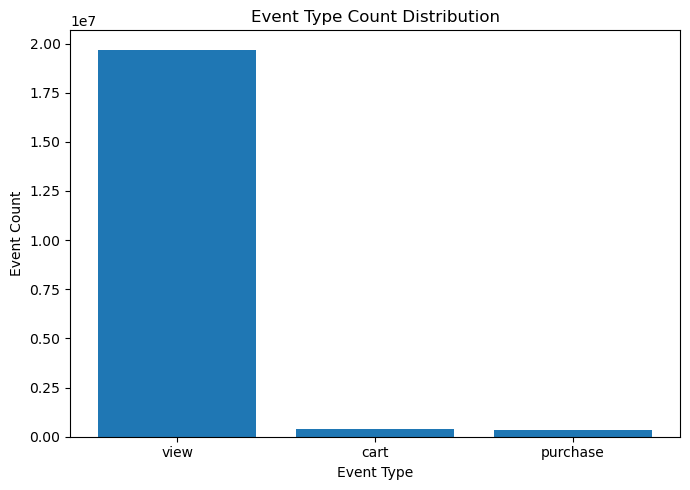

In [34]:
# 6. 行为类型分布可视化
plt.figure(figsize=(7, 5))

plt.bar(
    event_type_summary["event_type"],
    event_type_summary["event_count"]
)

plt.title("Event Type Count Distribution")
plt.xlabel("Event Type")
plt.ylabel("Event Count")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/event_type_count_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# 本节小结

1. 原始数据是一行一个用户行为事件，适合做漏斗分析和用户级特征工程。
2. view 行为明显多于 cart 和 purchase，符合电商转化漏斗特征。
3. purchase 行为占比较低，后续建模属于类别不平衡二分类任务。